<a href="https://colab.research.google.com/github/UCREL/pymusas_notebook/blob/main/PyMUSAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pre-requisite: HuggingFace user access token

In this tutorial we are going to download data from [HuggingFace](https://huggingface.co/) and potentially in the "extra" sections download models from HuggingFace, because of this it is **better but not required** to be logged into HuggingFace via a *user access token* with **read only** permissions so that it lowers the chance of being blocked from downloading said data due to rate limits that are in place for unknown users. The number of requests made using this notebook with your HuggingFace account will not exceed any API limit from a **free HuggingFace account**.

If you have a [HuggingFace](https://huggingface.co/) account (which are free (paid tiers are available but not required for this notebook)) please do consider creating a user access token following these instructions (it is also easy to sign up for users that do not have a HuggingFace account).

To get a HuggingFace user access token go to your [settings access token web page](https://huggingface.co/settings/tokens) and create a new "Fine-grained" token with "Read access to contents of all repos under your personal namespace" permission only, name it anything you want, i.e. "USS-PyMUSAS-2026" and after you have finished with this tutorial you can delete.


Google Colab specific:

Google Colab has a built-in "Secrets" feature that mimics environment variables perfectly.

1. Click the Key icon (Secrets) on the left sidebar.
2. Add a new secret with the Name: HF_TOKEN.
3. Paste your Hugging Face token into the Value field.
4. Toggle the switch to grant Notebook access.
5. Run this code in your notebook:

``` python
import os
from google.colab import userdata

# Colab requires this step to inject the secret into the environment
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# Now os.getenv works perfectly
hf_token = os.getenv("HF_TOKEN")
```

In [5]:
! pip install --index-url https://download.pytorch.org/whl/cpu torch
! pip install 'pymusas[neural]' spacy rich python-dotenv huggingface_hub

from pathlib import Path

from dotenv import load_dotenv

if Path(".env").exists():
    # Reads any environment variables stored in ".env" and sets them as environment
    # variables. This is used to load a local HuggingFace access token if it exists
    load_dotenv(".env")

def is_logged_into_huggingface() -> bool:
    from huggingface_hub import whoami
    from huggingface_hub.errors import HfHubHTTPError
    from huggingface_hub.utils import LocalTokenNotFoundError

    try:
        user_info = whoami()
        print(f"Logged in as: {user_info['name']}")
        return True
    except LocalTokenNotFoundError:
        print("❌ You are not logged in and no token was found on this system.")
    except HfHubHTTPError:
        print("❌ The token you provided is invalid, expired, or has been revoked.")
    return False

Looking in indexes: https://download.pytorch.org/whl/cpu


In [6]:
import subprocess
import sys
from enum import Enum

from rich import print as rprint
import spacy

In [3]:
https://huggingface.co/datasets/HuggingFaceFW/fineweb-2
https://huggingface.co/TeraflopAI
https://huggingface.co/datasets/NortheasternUniversity/big_patent
https://huggingface.co/datasets/Helsinki-NLP/euconst
https://huggingface.co/datasets/Helsinki-NLP/un_pc 

SyntaxError: invalid syntax (585840740.py, line 1)

In [7]:
# This contains language specific resources

class Languages(str, Enum):
    zh = "Chinese"
    da = "Danish"
    nl = "Dutch"
    en = "English"
    fi = "Finnish"
    it = "Italian"
    pt = "Portuguese"
    es = "Spanish"
    fr = "French"

LANGUAGE_2_PYMUSAS_RULE_MODEL: dict[Languages, str] = {
    Languages.zh: "cmn_dual_upos2usas_contextual_none",
    Languages.da: "da_dual_none_contextual_none",
    Languages.nl: "nl_single_upos2usas_contextual_none",
    Languages.en: "en_dual_none_contextual_none",
    Languages.fi: "fi_single_upos2usas_contextual_none",
    Languages.fr: "fr_single_upos2usas_contextual_none",
    Languages.it: "it_dual_upos2usas_contextual_none",
    Languages.pt: "pt_dual_upos2usas_contextual_none",
    Languages.es: "es_dual_upos2usas_contextual_none",
}

class SpacyModel(str, Enum):
    zh_md = "zh_core_web_md"
    da_md = "da_core_news_md"
    nl_md = "nl_core_news_md"
    en_md  = "en_core_web_md"
    fi_md = "fi_core_news_md"
    fr_md = "fr_core_news_md"
    it_md = "it_core_news_md"
    pt_md = "pt_core_news_md"
    es_md = "es_core_news_md"
    
    

LANGUAGE_2_SPACY_MODEL: dict[Languages, SpacyModel] = {
    Languages.zh: SpacyModel.zh_md,
    Languages.da: SpacyModel.da_md,
    Languages.nl: SpacyModel.nl_md,
    Languages.en: SpacyModel.en_md,
    Languages.fi: SpacyModel.fi_md,
    Languages.fr: SpacyModel.fr_md,
    Languages.it: SpacyModel.it_md,
    Languages.pt: SpacyModel.pt_md,
    Languages.es: SpacyModel.es_md
}

PYMUSAS_SPACY_MODEL_2_URL: dict[str, str] = {
    "cmn_dual_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/cmn_dual_upos2usas_contextual_none-0.4.0/cmn_dual_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "da_dual_none_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/da_dual_none_contextual_none-0.4.1/da_dual_none_contextual_none-0.4.1-py3-none-any.whl",
    "nl_single_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/nl_single_upos2usas_contextual_none-0.4.0/nl_single_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "en_dual_none_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/en_dual_none_contextual_none-0.4.0/en_dual_none_contextual_none-0.4.0-py3-none-any.whl",
    "fi_single_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/fi_single_upos2usas_contextual_none-0.4.0/fi_single_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "fr_single_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/fr_single_upos2usas_contextual_none-0.4.0/fr_single_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "it_dual_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/it_dual_upos2usas_contextual_none-0.4.0/it_dual_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "pt_dual_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/pt_dual_upos2usas_contextual_none-0.4.0/pt_dual_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "es_dual_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/es_dual_upos2usas_contextual_none-0.4.0/es_dual_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
}

SPACY_MODEL_2_URL: dict[str, str] = {
    "zh_core_web_md": "https://github.com/explosion/spacy-models/releases/download/zh_core_web_md-3.8.0/zh_core_web_md-3.8.0-py3-none-any.whl",
    "da_core_news_md": "https://github.com/explosion/spacy-models/releases/download/da_core_news_md-3.8.0/da_core_news_md-3.8.0-py3-none-any.whl",
    "nl_core_news_md": "https://github.com/explosion/spacy-models/releases/download/nl_core_news_md-3.8.0/nl_core_news_md-3.8.0-py3-none-any.whl",
    "en_core_web_md": "https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl",
    "fi_core_news_md": "https://github.com/explosion/spacy-models/releases/download/fi_core_news_md-3.8.0/fi_core_news_md-3.8.0-py3-none-any.whl",
    "fr_core_news_md": "https://github.com/explosion/spacy-models/releases/download/fr_core_news_md-3.8.0/fr_core_news_md-3.8.0-py3-none-any.whl",
    "it_core_news_md": "https://github.com/explosion/spacy-models/releases/download/it_core_news_md-3.8.0/it_core_news_md-3.8.0-py3-none-any.whl",
    "pt_core_news_md": "https://github.com/explosion/spacy-models/releases/download/pt_core_news_md-3.8.0/pt_core_news_md-3.8.0-py3-none-any.whl",
    "es_core_news_md": "https://github.com/explosion/spacy-models/releases/download/es_core_news_md-3.8.0/es_core_news_md-3.8.0-py3-none-any.whl"
}

# All examples come from Wikipedia articles and all except for Finnish and Spanish 
# come from the Wikipedia article about the Nile River. The Finnish and Spanish
# examples come from Wikipedia articles about the financial institutes that are banks (Pankki)
# and the country The Netherlands (Países Bajos) respectively.
SINGLE_SENTENCE_EXAMPLE: dict[Languages, str] = {
    Languages.zh: "尼罗河 是一条流經非洲東部與北部的河流，與中非地區的剛果河、非洲南部的赞比西河以及西非地区的尼日尔河並列非洲最大的四個河流系統。",
    Languages.da: "Mindst 65% af Nilens vand kommer fra Den Blå Nil, som udspringer ved Tanasøen i Etiopien.",
    Languages.nl: "De Nijl is met een lengte van 5499 tot 6695 km de langste of de op een na langste rivier van de wereld.",
    Languages.en: "The Nile is a major north-flowing river in Northeastern Africa.",
    Languages.fi: "Pankki on instituutio, joka tarjoaa finanssipalveluita, erityisesti maksuliikenteen hoitoa ja luotonantoa.",
    Languages.fr: "Le Nil est un fleuve d'Afrique. Avec une longueur d'environ 6 700 km, c'est avec le fleuve Amazone, le plus long fleuve du monde.",
    Languages.it: "Il Nilo è un fiume africano lungo 6.852 km che attraversa otto stati dell'Africa. Tradizionalmente considerato il fiume più lungo del mondo, contende il primato della lunghezza al Rio delle Amazzoni.",
    Languages.pt: "Todos estes estudos levam a que o comprimento de ambos os rios permaneça em aberto, continuando por isso o debate e como tal, continuando-se a considerar o Nilo como o rio mais longo.",
    Languages.es: "Los Países Bajos son un país soberano ubicado al noreste de la Europa continental y el país constituyente más grande de los cuatro que, junto con las islas de Aruba, Curazao y San Martín, forman el Reino de los Países Bajos.",
}

# Determines if the language can identify MWEs using the Rule Based system
LANGUAGE_MWE_IDENTIFICATION: dict[Languages, bool] = {
    Languages.zh: True,
    Languages.da: True,
    Languages.nl: False,
    Languages.en: True,
    Languages.fi: False,
    Languages.fr: False,
    Languages.it: True,
    Languages.pt: True,
    Languages.es: True,
}




# PyMUSAS Introduction - UCREL Summer School 2026

In this tutorial we show how to:
1. Load a Rule Based semantic tagger.
2. Tag a single sentence
3. Display tagged text;
    1. Using Pandas for easy data manipulation
    2. Histograms of POS and 

## Tagging text

Throughout this guide you have a choice of what language you would like to learn to tag text in, the languages you can choose from are:

In [8]:
print("\n".join([f"{language.name} - {language.value}" for language in Languages]))

zh - Chinese
da - Danish
nl - Dutch
en - English
fi - Finnish
it - Italian
pt - Portuguese
es - Spanish
fr - French


To choose a language simply assign the variable `LANGUAGE` to the given language code of choice:

In [9]:
LANGUAGE = Languages.en # English language is the default language
LANGUAGE = Languages.zh # English language is the default language

To start with we are going to show you how to use the [Rule Based Tagger](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger) as it is the quickest tagger and later on we will show you how to use the [Hybrid tagger](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/hybrid_tagger) and then [Neural Tagger](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/neural_tagger) for languages that the Rule Based and thus Hybrid tagger do not support.

> 📝 **Note:** We do support more languages for Rule/Hybrid taggers, but for ease of learning we are only focusing on this subset of languages, for a guide on all languages that PyMUSAS supports for Rule/Hybrid tagger see: [https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger)

### Downloading the relevant models

For all taggers, including the Neural tagger, we require a **tokenizer**, but the Rule Based tagger also uses the following information;
* Lemma/Stem (spaCy does not support this for; `Chinese`)
* Part Of Speech (POS)

Neither of these linguistic properties are required by the tagger but it does make it more accurate.

Therefore we are going to download the spaCy model that will provide us with our **pre-processing pipeline**; tokenizer, lemmatizer, and POS tagger and then download the **PyMUSAS semantic tagging model**. In this guide we use the **Medium size spaCy models** as they are a good trade off between speed and accuracy but you can use any spaCy model size, i.e. small, large, transformer.

> 📝 **Note:** in this tutorial we are using spaCy models to provide the pre-processing pipeline; tokenization, lemma, and POS tags but you can use other model providers like [Stanza](https://stanfordnlp.github.io/stanza/) and some of the languages we do not demonstrate here, like [Welsh](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger), do use other model providers.

In [10]:
def pip_install_model(wheel_url: str, spacy_model_name: str | None = None) -> None:
    """Install a model package from a wheel URL via pip.

    If `spacy_model_name` is provided and is already installed as a spaCy
    package, installation is skipped.

    Args:
        wheel_url: URL or path to the wheel file to install via pip.
        spacy_model_name: Name of the spaCy model package to check before
            installing. If None, no pre-check is performed and the wheel
            is always installed.

    Returns:
        None. Prints status messages indicating whether the model was
        already installed, installed successfully, or failed to install.
    """
    rprint(f"Pip installing the following wheel: {wheel_url}")
    
    if spacy_model_name is not None and spacy.util.is_package(spacy_model_name):
        rprint(f"[green]✓ {spacy_model_name} is already installed[/green]")
        return
    
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", wheel_url],
        capture_output=True,
        text=True
    )
    if result.returncode == 0:
        rprint(f"[green]✓ installed successfully: {wheel_url} [/green]")
    else:
        rprint(f"[red]✗ Failed to install: {wheel_url} {result.stderr}[/red]")


spacy_model_name = LANGUAGE_2_SPACY_MODEL[LANGUAGE].value
print(f"Going to download the following spaCy model for pre-processing: {spacy_model_name!r}")
spacy_model_wheel_url = SPACY_MODEL_2_URL[spacy_model_name]
pip_install_model(spacy_model_wheel_url, spacy_model_name=spacy_model_name)

pymusas_rule_model_name = LANGUAGE_2_PYMUSAS_RULE_MODEL[LANGUAGE]
print(f"Going to download the following PyMUSAS model for tagging: {pymusas_rule_model_name!r}")
pymusas_wheel_url = PYMUSAS_SPACY_MODEL_2_URL[pymusas_rule_model_name]
pip_install_model(pymusas_wheel_url, spacy_model_name=pymusas_rule_model_name)

Going to download the following spaCy model for pre-processing: 'zh_core_web_md'


Pip installing the following wheel: 
https://github.com/explosion/spacy-models/releases/download/zh_core_web_md-3.8.0/zh_core_web_md-3.8.0-py3-none-any.
whl

✓ zh_core_web_md is already installed

Going to download the following PyMUSAS model for tagging: 'cmn_dual_upos2usas_contextual_none'


Pip installing the following wheel: 
https://github.com/UCREL/pymusas-models/releases/download/cmn_dual_upos2usas_contextual_none-0.4.0/cmn_dual_upos2us
as_contextual_none-0.4.0-py3-none-any.whl

✓ cmn_dual_upos2usas_contextual_none is already installed

### Loading the tagger

The pre-processing and PyMUSAS rule based models are now installed we can load them into a spaCy pipeline like so:

In [11]:
# We load the pre-processing spaCy model without the NER model as that is not 
# needed and will speed up the tagging process
nlp = spacy.load(spacy_model_name, exclude=['ner'])

# We load the PyMUSAS rule based tagger
rule_based_pymusas_pipe = spacy.load(pymusas_rule_model_name)

# We add the PyMUSAS rule based tagger to the pre-processing spaCy pipeline
nlp.add_pipe('pymusas_rule_based_tagger', source=rule_based_pymusas_pipe)

# We can now see the whole spaCy pipeline
_ = nlp.analyze_pipes(pretty=True)


/Users/andrew/Documents/lancs/pymusas_notebook/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



============================= Pipeline Overview =============================

#   Component                   Assigns                       Requires      Scores             Retokenizes
-   -------------------------   ---------------------------   -----------   ----------------   -----------
0   tok2vec                     doc.tensor                                                     False      
                                                                                                          
1   tagger                      token.tag                                   tag_acc            False      
                                                                            pos_acc                       
                                                                            tag_micro_p                   
                                                                            tag_micro_r                   
                                                                

/Users/andrew/Documents/lancs/pymusas_notebook/.venv/lib/python3.13/site-packages/spacy/language.py:743: UserWarning: [W113] Sourced component 'pymusas_rule_based_tagger' may not work as expected: source vectors are not identical to current pipeline vectors.
  warnings.warn(Warnings.W113.format(name=source_name))


The `pymusas_rule_based_tagger` in `nlp.add_pipe('pymusas_rule_based_tagger', source=rule_based_pymusas_pipe)` is the spaCy `component name` for the PyMUSAS rule based tagger it in essence states that the data in `source` should be used to create a `pymusas_rule_based_tagger`, for more information about custom spaCy components see the [spaCy guide](https://spacy.io/usage/processing-pipelines#custom-components-factories) and if you want to know how we have created it for [PyMUSAS see the Rule Based component factory code](https://github.com/UCREL/pymusas/blob/e1adb79316eb62624648b8eacc22234701a8d2f6/pymusas/spacy_api/taggers/rule_based.py#L596).

The `nlp.add_pipe('pymusas_rule_based_tagger', source=rule_based_pymusas_pipe)`, as suggested, adds the PyMUSAS rule based tagger to the spaCy pre-processing pipeline, represented by `nlp`, thus creating a complete semantic tagging pipeline.

You are likely to see some components in that tagging pipeline that PyMUSAS does not use directly but might come in useful in the future, i.e. the `parser` is often used by spaCy for [sentence splitting](https://spacy.io/usage/linguistic-features#sbd) which is a valuable feature in a large scale tagging pipeline.

> **NOTE** by default PyMUSAS states it requires `token.pos` and `token.lemma` but it is not required by PyMUSAS but recommended, PyMUSAS will still work without either of those linguistic features.

> **Information** in most cases if the `tagger`, which is a POS tagger, exists it will output a `pos` tag normally through the `attribute_ruler` which will map the fine grained `token.tag` to `token.pos` see spaCy [model page](https://spacy.io/models) for more details.




### Single sentence tagging

Below we demonstrate how to use the spaCy tagging pipeline, `nlp`, with a single sentence that has come from an extract of a Wikipedia article, the pipeline will produce `tokens`, `lemmas`, `POS`, and `USAS semantic tags`:

In [12]:
sentence = SINGLE_SENTENCE_EXAMPLE[LANGUAGE]

# Process the document using the tagging pipeline
doc = nlp(sentence)

# For Chinese the spaCy pipeline does not support lemmatization
has_lemma = False if LANGUAGE in {Languages.zh} else True

header_text = f'{"Text":<20}{"Lemma":<20}{"POS":<8}USAS Tags'
if not has_lemma:
    header_text = f'{"Text":<20}{"POS":<8}USAS Tags'

print(header_text)
for token in doc:
    token_data_text = f'{token.text:<20}{token.lemma_:<20}{token.pos_:<8}{token._.pymusas_tags}'
    if not has_lemma:
        token_data_text = f'{token.text:<20}{token.pos_:<8}{token._.pymusas_tags}'
    print(token_data_text)

Text                POS     USAS Tags
尼罗河                 NOUN    ['Z2']
是                   VERB    ['A3', 'Z5']
一                   NUM     ['N1']
条                   NUM     ['G2.1/P1', 'S7.4-', 'A1.7+', 'S8-']
流經                  VERB    ['Z99']
非洲                  PROPN   ['Z2']
東部                  NOUN    ['Z99']
與北部                 PROPN   ['Z99']
的                   PART    ['Z5']
河流                  NOUN    ['W3/M4', 'N5+']
，                   PUNCT   ['PUNCT']
與                   ADP     ['Z99']
中非                  PROPN   ['Z99']
地區                  NOUN    ['Z99']
的                   PART    ['Z5']
剛果河                 PROPN   ['Z99']
、                   PUNCT   ['PUNCT']
非洲                  PROPN   ['Z2']
南部                  NOUN    ['M6']
的                   PART    ['Z5']
赞比西河                NOUN    ['Z99']
以及                  CCONJ   ['N5++', 'N5.2+', 'A13.3', 'Z5']
西非                  PROPN   ['Z99']
地区                  NOUN    ['A1.1.1', 'B3/X1', 'G1.1c', 'W3', 'F4/M7'

As you might notice for all of the languages the POS tags are from the [universal POS tag schema](https://universaldependencies.org/u/pos/), PyMUSAS can and does support other POS tag schemas (i.e. [Welsh we support the basic CorCencC POS tagset](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger#welsh)).

The USAS tags also come in a list of USAS tags whereby the first tag in the list is the most likely tag, and the tag we will use later in our analysis.

Also you can see that the USAS tags can contain affix symbols, i.e. `+`, `-`, `c`, etc as well as some being a multi tag, i.e. `F4/M7`. We can actually process the tags to get all of this information into a structured format using the [USAS-Validator package](https://github.com/UCREL/USAS-Validator):

In [13]:
# We install the USAS-Validator package
! pip install git+https://github.com/UCREL/USAS-Validator.git

  Cloning https://github.com/UCREL/USAS-Validator.git to /private/var/folders/nt/06l78y250438cqvg7fmslzsw0000gn/T/pip-req-build-x6ojuwi2
  Running command git clone --filter=blob:none --quiet https://github.com/UCREL/USAS-Validator.git /private/var/folders/nt/06l78y250438cqvg7fmslzsw0000gn/T/pip-req-build-x6ojuwi2
  Resolved https://github.com/UCREL/USAS-Validator.git to commit f12f39152e51b0fcc7f14c050029be8e06fc65c2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [14]:
from usas_validator.utils import parse_usas_token_group

# In this example because of the whitespace it represents two USAS tags `Z1` and `N1+++/K5`
usas_tag_groups = parse_usas_token_group("Z1 N1+++/K5", strict=False)
# We can get the first tags data:
first_tag = usas_tag_groups[0]
print(f"First tag data: {first_tag}")
# of which we can get just the tag through:
print(f"First tag: {first_tag.tags[0].tag}")

# We can get the second tags data:
second_tag = usas_tag_groups[1]
print(f"Second tag data: {second_tag}")
# of which we can get just the tag through:
print(f"Second tags: {'/'.join(tag.tag for tag in second_tag.tags)}")

# If the tag is not valid it will be ignored
non_valid_tag = parse_usas_token_group("OT1 L1", strict=False)
print(f"Non valid tags are ignored: {non_valid_tag}")


First tag data: tags=[USASTag(tag='Z1', number_positive_markers=0, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)]
First tag: Z1
Second tag data: tags=[USASTag(tag='N1', number_positive_markers=3, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False), USASTag(tag='K5', number_positive_markers=0, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)]
Second tags: N1/K5
Non valid tags are ignored: [USASTagGroup(tags=[USASTag(tag='L1', number_positive_markers=0, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)])]


We can see that through the USAS Validator package we can extract out the tag data into a structured format;
1. Breaks a multi tag USAS tag into each individual tag as shown in the `Z1 N1+++/K5` example.
2. For each individual tag you can get a break down of affix symbols, as shown by `N1+++` have `number_positive_markers=3`.
3. For tags that do not conform to the expected USAS tagset regular expression format `[A-Z](\d+)((\.\d+)+)?` they are ignored as shown by `OT1 L1` whereby the `OT1` tag is not in the parsed list of tags.

What this function does not do, but we can add it in is to ignore tags that do not exist in the USAS tagset but do conform to the regular expression format like:

In [15]:
parse_usas_token_group("B10", strict=False)

[USASTagGroup(tags=[USASTag(tag='B10', number_positive_markers=0, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)])]

`B10` is not a valid USAS tag, we can check if it is part of the USAS tagset using the `load_usas_mapper` function, this function returns a dictionary of `USAS tags` to `Description` which will also be useful later on to explain what the tags mean:

In [16]:
from usas_validator.utils import load_usas_mapper

usas_tag_description_mapper = load_usas_mapper(None, None)

for tag, description in usas_tag_description_mapper.items():
    print(f"{tag!r} - {description!r}")

print(f'Is `B10` in `usas_tag_description_mapper`: {"B10" in usas_tag_description_mapper}')

'A1.1.1' - 'title: General actions, making etc. description: General/abstract terms relating to an activity/action (e.g. act, adventure, approach, arise); a characteristic/feature (e.g. absorb, attacking, automatically); aconstruction/craft and/or the action of constructing/crafting (e.g. arrange, assemble, bolts, boring, break)'
'A1.1.2' - 'title: Damaging and destroying description: General/abstract terms depicting damage/destruction/demolition/pollution, etc'
'A1.2' - 'title: Suitability description: General/abstract terms relating to appropriateness, suitability, aptness, etc'
'A1.3' - 'title: Caution description: General/abstract terms relating to vigilance/care/prudence, or the lack of.'
'A1.4' - 'title: Chance, luck description: General/abstract terms depicting likelihood/probability/providence, or the lack of.'
'A1.5' - 'title: Use description:'
'A1.5.1' - 'title: Using description: General/abstract terms denoting use, or the lack of'
'A1.5.2' - 'title: Usefulness description: 

To make everything easier to process we can create a function that will both check if the USAS tag conforms to the expected format of a USAS tag and it is in the USAS tag set, below is the function `filter_non_usas_valid_tags` with an example

In [17]:
from usas_validator.usas_tag import USASTagGroup, USASTag

def filter_non_usas_valid_tags(usas_tag_string: str, valid_usas_tags: set[str]) -> list[USASTagGroup]:
    """Filter a USAS tag string to only include tags present in a given set of valid tags.

    Parses the input string into :class:`USASTagGroup` objects (in non-strict mode,
    so malformed tags are skipped rather than raising errors), then removes any
    individual :class:`USASTag` whose base tag is not in ``valid_usas_tags``.
    Tag groups that become empty after filtering are dropped entirely.

    Parameters
    ----------
    usas_tag_string : str
        A space-separated string of USAS tag groups, e.g. ``"Z2/S2mf E3-"``.
    valid_usas_tags : set[str]
        A set of acceptable base USAS tag strings (e.g. ``{"Z2", "E3"}``).
        Typically obtained from :func:`~usas_validator.utils.load_usas_mapper`.

    Returns
    -------
    list[USASTagGroup]
        A list of :class:`USASTagGroup` objects containing only tags whose base
        tag appears in ``valid_usas_tags``. Groups with no remaining valid tags
        are excluded.

    Examples
    --------
    >>> valid = {"Z2", "E3"}
    >>> filter_non_usas_valid_tags("Z2/S2mf E3-", valid)
    [USASTagGroup(tags=[USASTag(tag='Z2', ...)]), USASTagGroup(tags=[USASTag(tag='E3', ...)])]

    >>> filter_non_usas_valid_tags("Z2/S2mf E3-", {"Z2"})
    [USASTagGroup(tags=[USASTag(tag='Z2', ...)])]
    """
    all_valid_usas_tag_groups = parse_usas_token_group(usas_tag_string, strict=False)
    filtered_usas_tag_groups = []
    for usas_tag_group in all_valid_usas_tag_groups:
        filtered_usas_tags = [usas_tag for usas_tag in usas_tag_group.tags
                                             if usas_tag.tag in valid_usas_tags]
        if filtered_usas_tags:
            filtered_usas_tag_groups.append(USASTagGroup(tags=filtered_usas_tags))
    return filtered_usas_tag_groups

valid_usas_tags_set = set(usas_tag_description_mapper.keys())
filter_non_usas_valid_tags("B10 OT1 N1+++", valid_usas_tags_set)

[USASTagGroup(tags=[USASTag(tag='N1', number_positive_markers=3, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)])]

As we can see the function `filter_non_usas_valid_tags` filters out the `B10` and `OT1` non-valid tags and keeps the `N1+++` tag.

In some languages such as English, the tagger can also identify and tag Multi Word Expressions (MWE).  We can see these, in much the same way as the single words above:

In [18]:
if not LANGUAGE_MWE_IDENTIFICATION.get(LANGUAGE, False):
    print(f'We do not support MWE identification for: {LANGUAGE.value!r}')

print(f'Text\tPOS\tMWE start and end index\tUSAS Tags')

for token in doc:
    start, end = token._.pymusas_mwe_indexes[0]
    if (end - start) > 1:
        print(f'{token.text}\t{token.pos_}\t{(start, end)}\t{token._.pymusas_tags}')

Text	POS	MWE start and end index	USAS Tags
最	ADV	(28, 30)	['A11.1+', 'N5+++', 'N3.2+++', 'A11.1+++', 'N5.1+', 'O2/M4', 'O3']
大	VERB	(28, 30)	['A11.1+', 'N5+++', 'N3.2+++', 'A11.1+++', 'N5.1+', 'O2/M4', 'O3']


> **Information** the reason `token._.pymusas_mwe_indexes` is a list of (start and end) tuples is that a MWE can be non-continuos, however the current version of PyMUSAS does not support identification of non-continuos MWEs, yet.

## Tagging a larger dataset

Moving beyond tagging a single sentence to tagging a whole corpus. We are going to tag the first 100,000 tokens of the language's given Wikipedia using the [FineWiki](https://huggingface.co/datasets/HuggingFaceFW/finewiki) dataset from HuggingFace, we choose this as it is a "cleaned" Wikipedia dataset, it covers 325 languages, Wikipedia covers many topics thus making it a good candidate as a reference corpus, and the data has an open license ([CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/deed.en)).

Also as the dataset is on HuggingFace hub we can easily access it and download the data via streaming. Streaming the data means that instead of download all of the data all at once we download in essence one chunk of data at a time allowing us to process the data while it downloads, see [the streaming documentation for more information on this.](https://huggingface.co/docs/datasets/en/stream)

First we are going to install [HuggingFace datasets package](https://huggingface.co/docs/datasets/en/index) to allow us to programmatically stream the download of the Wikipedia dataset:

In [19]:
! pip install datasets

Below we setup the streaming of the dataset and print out the first 100 samples (shortened to the first 100 characters) to show what the data looks like:

In [20]:
from statistics import mean, stdev, median

from datasets import load_dataset

# ID of the dataset we want to download
huggingface_wikipedia_id = "HuggingFaceFW/finewiki"
# for this dataset it only has one split which is `train`
dataset_split = "train"
# The name of the dataset configuration we want, in this case which language
# subset we want to use
hf_dataset_config = "zh"
# The dataset fields/columns we want from the dataset, in this case we only
# want the text column, which is markdown text format. In selecting a subset of 
# the columns we speed up the downloading.
dataset_columns = ["text"]

# The dataset iterable
dataset_iterable = load_dataset(huggingface_wikipedia_id,
                                                 name=hf_dataset_config,
                                                 split=dataset_split,
                                                 streaming=True,
                                                 columns=dataset_columns)
sample_character_counts: list[int] = []
for sample_index, sample in enumerate(dataset_iterable):
    sample_text = sample['text']
    character_count = len(sample_text)
    sample_character_counts.append(character_count)
    print(f"Index: {sample_index} (sample length in characters {character_count}): {sample_text[:100]}")
    if sample_index == 100:
        break
print('Mean (standard deviation) and median of the character counts respectively: '
      f'{mean(sample_character_counts):.2f} '
      f'({stdev(sample_character_counts):.2f}) '
      f'{median(sample_character_counts):.2f}')


Index: 0 (sample length in characters 87): # 2004年夏季残疾人奥林匹克运动会哥伦比亚代表团
2004年夏季残疾人奥林匹克运动会哥伦比亚代表团是哥伦比亚派出的2004年夏季残疾人奥林匹克运动会代表团。未获得奖牌。

Index: 1 (sample length in characters 88): # 2004年夏季残疾人奥林匹克运动会克罗地亚代表团
2004年夏季残疾人奥林匹克运动会克罗地亚代表团是克罗地亚派出的2004年夏季残疾人奥林匹克运动会代表团。获得4枚铜牌。

Index: 2 (sample length in characters 87): # 2004年夏季残疾人奥林匹克运动会多米尼加代表团
2004年夏季残疾人奥林匹克运动会多米尼加代表团是多米尼加派出的2004年夏季残疾人奥林匹克运动会代表团。未获得奖牌。

Index: 3 (sample length in characters 92): # 2004年夏季残疾人奥林匹克运动会埃及代表团
2004年夏季残疾人奥林匹克运动会埃及代表团是埃及派出的2004年夏季残疾人奥林匹克运动会代表团。获得6枚金牌、9枚银牌和8枚铜牌。

Index: 4 (sample length in characters 87): # 2004年夏季残疾人奥林匹克运动会萨尔瓦多代表团
2004年夏季残疾人奥林匹克运动会萨尔瓦多代表团是萨尔瓦多派出的2004年夏季残疾人奥林匹克运动会代表团。未获得奖牌。

Index: 5 (sample length in characters 96): # 2004年夏季残疾人奥林匹克运动会匈牙利代表团
2004年夏季残疾人奥林匹克运动会匈牙利代表团是匈牙利派出的2004年夏季残疾人奥林匹克运动会代表团。获得1枚金牌、8枚银牌和10枚铜牌。

Index: 6 (sample length in characters 87): # 2008年夏季残疾人奥林匹克运动会亚美尼亚代表团
2008年夏季残疾人奥林匹克运动会亚美尼亚代表团是亚美尼亚派出的2008年夏季残疾人奥林匹克运动会代表团。未获得奖牌。

Index: 7 (sample length in characters 87): # 2008年夏季残疾人奥林匹克运动会孟加拉国代表

As you can see the data is in Markdown format and the lengths of the texts can vary a lot based on the character counts showing that the data can be both long and short.

We are now going to create a reference corpus for USAS semantic tags, in essence this is a dictionary of USAS tags and the number of times they occur in the corpus;
1. We are going to sample the first 100,000 tokens
2. For each sample we are going to process the text through tagging pipeline (`nlp`)
3. We are going to remove any token that is;
    1. Punctuation denoted through the POS tag `PUNCT` (coming from the [universal POS tag schema](https://universaldependencies.org/u/pos/))
    2. That is an unknown USAS tag, represented as `Z99`
4. Filter out any non-valid USAS tags using the `` function.
5. Only keep the most likely USAS tag
6. Only use the tag of the USAS tag and not keep any of the affixes.
7. To make the analysis easier split multi tag USAS tags into their separate tags, i.e. `Z2+/C1` will become `Z2` and `C1` whereby we will store all of the separate tags.

In [ ]:
import time
from collections import Counter

# We re-create the dataset iterable as once you start an iterable in Python you
# cannot reverse it without re-creating it

# The dataset iterable
dataset_iterable = load_dataset(huggingface_wikipedia_id,
                                                 name=hf_dataset_config,
                                                 split=dataset_split,
                                                 streaming=True,
                                                 columns=dataset_columns)
# USAS counter
reference_usas_counter = Counter()

# Number of tokens to process, default 100,000
reference_tokens_to_process = 100_000

# Keep track of how long it took to process
start_time = time.perf_counter()

pos_tags_to_ignore = set({'PUNCT'})
usas_tags_to_ignore = set({'Z99'})

token_count = 0
for sample in dataset_iterable:
    if token_count > reference_tokens_to_process:
        print(f'Time taken to process the data: {time.perf_counter() - start_time}')
        break
    doc = nlp(sample['text'])
    for token in doc:
        # Skip over punctuation tokens
        token_pos = token.pos_
        if token_pos in pos_tags_to_ignore:
            continue
        token_text = token.text
        
        token_usas = token._.pymusas_tags
        # No USAS tags
        if not token_usas:
            continue
        most_likey_tag = token_usas[0]
        filtered_most_likey_tag = filter_non_usas_valid_tags(most_likey_tag, valid_usas_tags_set)
        # No USAS tags after filtering
        if not filtered_most_likey_tag:
            continue
        for usas_tag_object in filtered_most_likey_tag[0].tags:
            tag = usas_tag_object.tag
            if tag in usas_tags_to_ignore:
                continue
            reference_usas_counter.update([tag])
    token_count += len(doc)

print(f"Top 5 most common USAS tags:")
for tag, count in reference_usas_counter.most_common(5):
    print(f'Tag: {tag} Count: {count:,} Tag Description: {usas_tag_description_mapper[tag]}')

Time taken to process the data: 46.1095050829972
Top 5 most common USAS tags: [('N1', 6687), ('Z5', 4597), ('A1.1.1', 1654), ('Z2', 1448), ('S2', 1002)]


Now that we have this data we can compare it to a `target` text that you might be studying, e.g. a text from a specific domain like finance or legal. In our case depending on the language we are going to compare it to;
* European Constitution (EC)
* United Nations (UN) records and documents.

Both texts are very similar in that they come from an international orgainzation and that the EC document is a treaty of which the UN either discuss treaties or create documents that can be similar in nature.

In [48]:
usas_tag_description_mapper['Z99']

'title: Unmatched description: Mis-spellings or words that have not been included in the lexicon as yet'

In [51]:
for sample in fw:
    print()
    print(sample.keys())
    print()
    break


dict_keys(['text'])



## Manipulating and displaying tagged text

### Pandas

[Pandas Dataframes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) are very similar to tables in spreadsheets, they allow you to perform different statistics analyses to the data they are storing as well as quick manipulation of that data.

First we are going to download and instal Pandas

In [38]:
! pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 7.6 MB/s  0:00:017.7 MB/s eta 0:00:01:01


And now we can re-tag the single sentence we used before and display the `tokens`, `POS`, and `USAS` tags in a Pandas DataFrame:

In [39]:
# load in pandas so we can create dataframs
import pandas as pd

# We need to create lists for each of the columns
tokens = []
pos = []
pymusas_tags = []

# Sentence we are tagging
sentence = SINGLE_SENTENCE_EXAMPLE[LANGUAGE]
# Process the document using the tagging pipeline
doc = nlp(sentence)

for token in doc:
    tokens.append(token.text)
    pos.append(token.pos_)
    pymusas_tags.append(token._.pymusas_tags)


# We need to create the dataframe with the columns we will require.
# and assign each list to a column
df = pd.DataFrame({'tokens': tokens,
                   'POS': pos,
                   'USAS_Tags': pymusas_tags
                  })
df

,tokens,POS,USAS_Tags
0,尼罗河,NOUN,[Z2]
1,是,VERB,"[A3, Z5]"
2,一,NUM,[N1]
3,条,NUM,"[G2.1/P1, S7.4-, A1.7+, S8-]"
4,流經,VERB,[Z99]
5,非洲,PROPN,[Z2]
6,東部,NOUN,[Z99]
7,與北部,PROPN,[Z99]
8,的,PART,[Z5]
9,河流,NOUN,"[W3/M4, N5+]"


As you can see the data is now in table format, you can now get just the first 5 rows of one column like so:

In [41]:
df['tokens'].head(5)

0    尼罗河
1      是
2      一
3      条
4     流經
Name: tokens, dtype: str

You can save the data into various formats, like `excel` or `csv`, for a full list of input and output (export) formats see [https://pandas.pydata.org/docs/reference/io.html](https://pandas.pydata.org/docs/reference/io.html):

In [44]:
# Exports the table above to CSV format without the index (row numbers)
df.to_csv("single_sentence_export.csv", index=False)

### Histograms of Part Of Speech frequency

Pandas Dataframes allows you to easily display data with plots using another Python package called `matplotlib`, of which we will install `matplotlib` now:

In [45]:
! pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 7.5 MB/s  0:00:01 eta 0:00:010:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 7.2 MB/s  0:00:007.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 7.5 MB/s  0:00:00m 7.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


<Axes: xlabel='POS'>

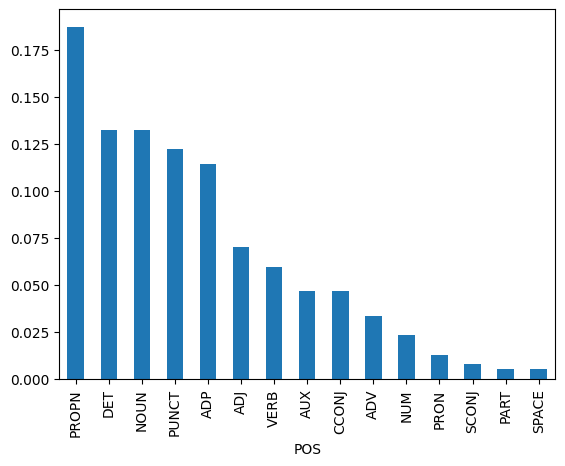

In [15]:
# we need to load in the plotting and dataframes library
import matplotlib.pyplot as plt
import pandas

# create the plot
data = df
fig, ax = plt.subplots()

# Extract the column we need, "POS", and count how many times each
# POS appears, and normalise the values
data['POS'].value_counts(normalize=True).plot(ax=ax, kind='bar')

We can also do the same with the text and count how many times each word appears in the text

<Axes: xlabel='Text'>

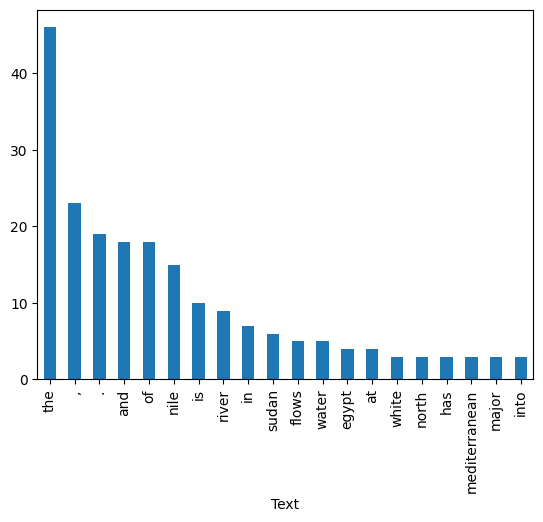

In [16]:

# This time we need to limit the number of words displayed
# otherwise the plot will have a long tail.
# We use head(n=20) to display the top 20 words used.
fig, ax = plt.subplots()
df['Text'].str.lower().value_counts().head(n=20).plot(ax=ax, kind='bar')

Unfortunatly punctuation is some of the highest usage.  If we do not want punctuation to be counted in the word
count, we can exclude it as so:

<Axes: xlabel='Text'>

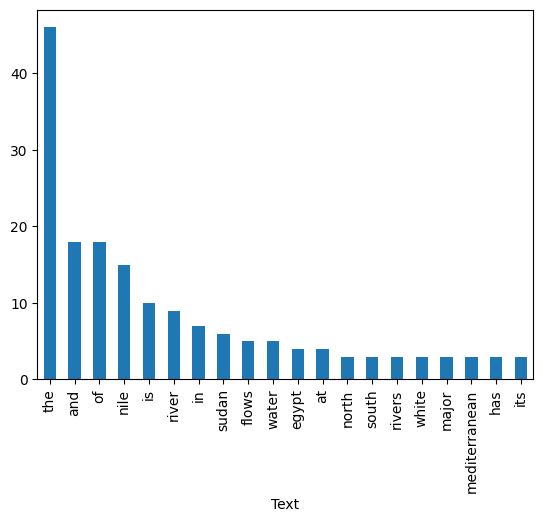

In [17]:
fig, ax = plt.subplots()
df.loc[df['POS']!='PUNCT', 'Text'].str.lower().value_counts().head(n=20).plot(ax=ax, kind='bar')

We can also exclude a set/list of specified words that might not be of interest, e.g. `the`, `and`, etc sometimes called stop words:

<Axes: xlabel='Text'>

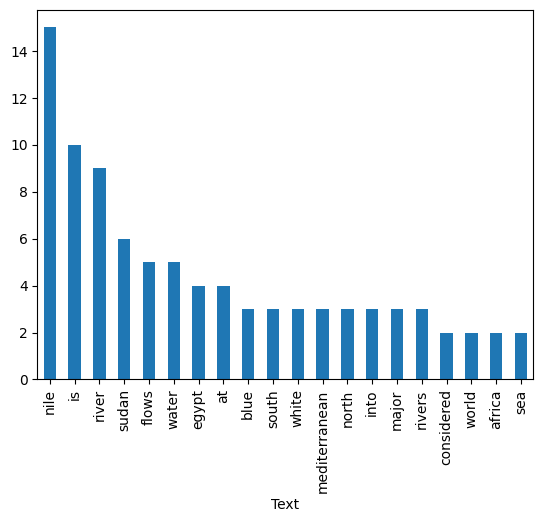

In [18]:
fig, ax = plt.subplots()
excluded_words = set(['the', 'and', 'of', 'in', 'its', 'has'])
df.loc[(df['POS']!='PUNCT') & (~df['Text'].str.lower().isin(excluded_words)), 'Text']\
    .str.lower().value_counts()\
    .head(n=20).plot(ax=ax, kind='bar')

## Comparison of frequency

One useful analysis is to compare the frequency of words apperances in two different texts.  To do this we will need to load in both sets (the new one is the wikipedia article on the river Danube).

We will load in both texts, and pass them through the tagger, then we will save just the words and P.O.S. from each text.

In [19]:
import pandas as pd

text = []
pos = []

with open('Nile.txt') as f:
    contents = f.read()
    output_doc = nlp(contents)
    for token in output_doc:
        text.append(token.text)
        pos.append(token.pos_)

nile_data = pd.DataFrame({'Text': text, 'POS': pos})


text = []
pos = []

danube_file = Path('danube.txt')
if not danube_file.exists():
  print('Cannot found the Danube text file, downloading the file')
  import requests
  response = requests.get("https://raw.githubusercontent.com/UCREL/pymusas_notebook/refs/heads/main/danube.txt")
  with danube_file.open('w', encoding='utf-8') as danube_fp:
    danube_fp.write(response.text)
  print('Danube text file downloaded')

with open('danube.txt') as f:
    contents = f.read()
    output_doc = nlp(contents)
    for token in output_doc:
        text.append(token.text)
        pos.append(token.pos_)

danube_data = pd.DataFrame({'Text': text, 'POS': pos})


Cannot found the Danube text file, downloading the file
Danube text file downloaded


Now we need to clean up the text.  We will place a filter on the dataframe to exclude any row where the POS column is either 'PUNCT' or 'SPACE' to remove white space and punctuation.   Then we will ensure all text is lower case and count how many occurances of each type there are.

In [20]:
nile_data_cleaned = nile_data.loc[(nile_data['POS']!='PUNCT') & (nile_data['POS'] != 'SPACE'), 'Text'].str.lower().value_counts()

danube_data_cleaned = danube_data.loc[(danube_data['POS']!='PUNCT') & (danube_data['POS']!='SPACE'), 'Text'].str.lower().value_counts()

Now we need to combine the datasets and keep only entries where the word occurs in both text.  We then limit this to the top 20 words.

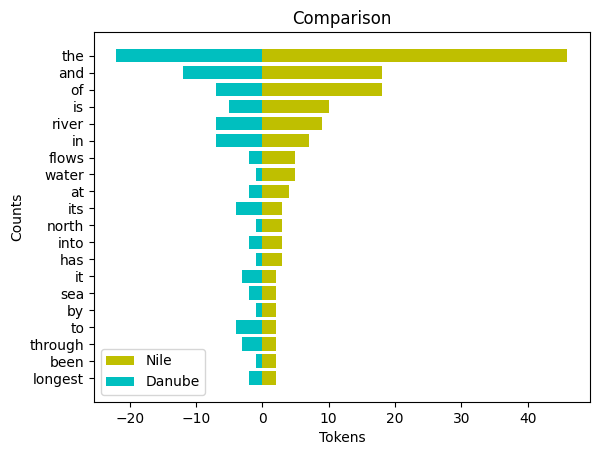

In [21]:
comparison = pd.concat([nile_data_cleaned, danube_data_cleaned], axis=1, join = "inner").head(n=20)

comparison.columns = ['Nile', 'Danube']

import numpy as np
import matplotlib.pyplot as plt

plt.barh(comparison.index[::-1], comparison["Nile"][::-1], align='center', color = 'y', label="Nile")
plt.barh(comparison.index[::-1], -comparison["Danube"][::-1], align='center', color = 'c', label="Danube")
plt.title("Comparison")
plt.ylabel("Counts")
plt.xlabel("Tokens")
plt.legend()
plt.show()




In the comparison bar graph above we can see that the word `of` and `the` appear more often in the Nile text than the Danube text, in the Nile text `of` and `the` appear about 20 and 40 times whereas in the Danube text they appear about 10 and 20 times respectively.

## Keyness value

The comparison above is great to see a quick overview of the difference between the two texts. In this section we want to find which words are "key" words whereby they are used more in one text than the other, to do this we are going to calculate the [log-likelihood](https://ucrel.lancs.ac.uk/llwizard.html) (see [Rayson, P. and Garside, R. (2000)](https://ucrel.lancs.ac.uk/people/paul/publications/rg_acl2000.pdf) on the use of comparing corpora using log-likelihood with the USAS semantic tags) of each word to get the words keyness value. For clarity we are going to use the `Nile` text as the `research/target text` and the `Danube` text as the `reference/normative text`. To **note** that you would normally use a larger corpus/text as the reference text, e.g. BNC or a word frequency list from a large representative corpus.

In [22]:
import math

def keyness(a, b, c, d):
    E1 = c * (a + b) / (c + d)
    E2 = d * (a + b) / (c + d)
    G2 = 2 * ( (a*math.log(a/E1) ) + (b * math.log(b/E2)) )
    return G2

danube_total = danube_data_cleaned.sum()
nile_total = nile_data_cleaned.sum()

under_over = {True: 'Over', False: 'Under'}

comparison["keyness"] = comparison.apply(lambda x: keyness(x["Nile"], x["Danube"], nile_total, danube_total), axis=1)
comparison["use"] = comparison.apply(lambda x: under_over[x["Nile"] > x["Danube"]], axis=1)

Below we can see the tokens ordered by keyness value, if the keyness value is high it indicates the token is either used more or a less in the `research text` (Nile text in this case) than the `reference text` (Danube text in this case) in essence the higher the keyness value of the token use is more different and therefore interesting to investigate. We have added to the table below the column `use` to indicate if the token is `over` used or `under` used.

In [23]:
comparison.sort_values(by='keyness', ascending=False)

,Nile,Danube,keyness,use
Text,,,,
the,46,22,4.157371,Over
of,18,7,2.871796,Over
water,5,1,2.095473,Over
to,2,4,1.198436,Under
is,10,5,0.772092,Over
flows,5,2,0.747467,Over
has,3,1,0.651057,Over
north,3,1,0.651057,Over
it,2,3,0.485455,Under


We can then generate a word cloud of the over used tokens whereby the token text size is based off it's keyness value like so:

In [24]:
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install wordcloud
from wordcloud import WordCloud

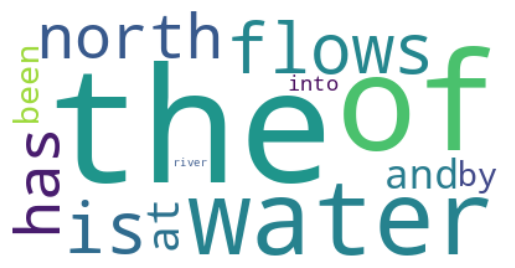

In [25]:
wordcloud = WordCloud(background_color="white").generate_from_frequencies(comparison.loc[comparison['use']=='Over']["keyness"])
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [28]:
# Hybrid Tagger

In [ ]:
# Languages that are not covered by Rule-Hybrid -- Neural use case